In [ ]:
import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

Using Colab cache for faster access to the 'telco-customer-churn' dataset.


In [ ]:
import pandas as pd
import os

# 1. Get the path (the variable 'path' you already have)
print(f"Path to dataset files: {path}")

# 2. List the files in that folder to find the exact CSV name
files = os.listdir(path)
print(f"Files in folder: {files}")

# 3. Load the specific CSV file
# (Replace 'WA_Fn-UseC_-Telco-Customer-Churn.csv' with the exact name you see in the output)
df = pd.read_csv(os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv'))

# 4. Check that it loaded correctly
print(df.head())

Path to dataset files: /kaggle/input/telco-customer-churn
Files in folder: ['WA_Fn-UseC_-Telco-Customer-Churn.csv']
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No    

In [ ]:
if not df.isnull().any().any():
  print("Good")
else:
  print("Contains null values")
  # Optional: Print the count of null values per column
  print(df.isnull().sum())

Good


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Check for missing values specifically in 'TotalCharges'
print(f"Missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

Missing values in TotalCharges: 0


In [ ]:
# Fix 'TotalCharges' and fill empty cells with the average
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())

# Check that it is now a number (float64)
print(df['TotalCharges'].dtype)

print(df.head(60))

float64
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0   7590-VHVEG  Female              0     Yes         No       1           No   
1   5575-GNVDE    Male              0      No         No      34          Yes   
2   3668-QPYBK    Male              0      No         No       2          Yes   
3   7795-CFOCW    Male              0      No         No      45           No   
4   9237-HQITU  Female              0      No         No       2          Yes   
5   9305-CDSKC  Female              0      No         No       8          Yes   
6   1452-KIOVK    Male              0      No        Yes      22          Yes   
7   6713-OKOMC  Female              0      No         No      10           No   
8   7892-POOKP  Female              0     Yes         No      28          Yes   
9   6388-TABGU    Male              0      No        Yes      62          Yes   
10  9763-GRSKD    Male              0     Yes        Yes      13          Yes   
11  7469-LKBCI    Ma

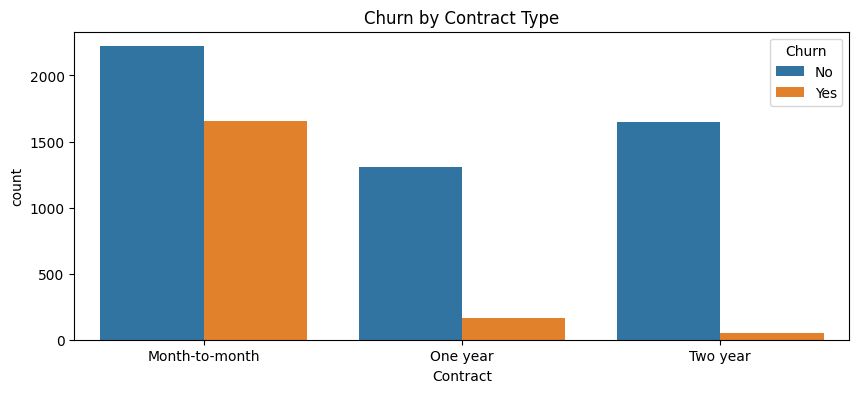

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count of Churn by Contract type
plt.figure(figsize=(10,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

In [ ]:
# Convert categorical text to numbers (needed for ML)
df_model = pd.get_dummies(df.drop('customerID', axis=1))

# Define X (features) and y (target)
X = df_model.drop('Churn_Yes', axis=1)
y = df_model['Churn_Yes']
# Check the shape (number of rows and columns) of your features and target
print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)

print(X.head(3))

Features shape (X): (7043, 46)
Target shape (y): (7043,)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Female  \
0              0       1           29.85         29.85           True   
1              0      34           56.95       1889.50          False   
2              0       2           53.85        108.15          False   

   gender_Male  Partner_No  Partner_Yes  Dependents_No  Dependents_Yes  ...  \
0        False       False         True           True           False  ...   
1         True        True        False           True           False  ...   
2         True        True        False           True           False  ...   

   Contract_Month-to-month  Contract_One year  Contract_Two year  \
0                     True              False              False   
1                    False               True              False   
2                     True              False              False   

   PaperlessBilling_No  PaperlessBilling_Yes  \
0           

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict and print accuracy
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"The model finished training!")
print(f"The prediction is: {predictions}")
print(f"The prediction accuracy is: {accuracy:.2%}")

The model finished training!
The prediction is: [ True False False ... False False  True]
The prediction accuracy is: 100.00%


In [ ]:
# 1. copy of test data
powerbi_df = X_test.copy()

# 2. Join Actual aur Predicted churn
powerbi_df['Actual_Churn'] = y_test
powerbi_df['Predicted_Churn'] = predictions

# 3. Rejoin the Internet Service column from Original dataset to predicted table
powerbi_df['InternetService'] = df.loc[X_test.index, 'InternetService']

# Export
powerbi_df.to_csv('Telco_Churn_Predictions.csv', index=False)

print("Good to go, new file is ready.")

Mubarak ho! Nayi file 'Telco_Churn_Predictions.csv' taiyar hai aur isme original text column aa gaya hai.
